In [ ]:
import os
import zipfile
from google.colab import drive

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/dataset.zip'
extract_path = '/content/temp_data'

if not os.path.exists(extract_path):
    print("extracting file")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("done")
else:
    print("data already on drive")

DATA_DIR = os.path.join(extract_path, 'dataset')

Mounted at /content/drive
extracting file
done


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1499 images belonging to 5 classes.
Found 373 images belonging to 5 classes.


In [ ]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights_dict = dict(enumerate(class_weights))

for cls, weight in zip(train_data.class_indices.keys(), class_weights):
    print(f"  - {cls}: {weight:.4f}")

  - building: 1.1022
  - car: 0.7869
  - lab: 1.7034
  - person: 1.1711
  - tree: 0.7242


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    layers.Dropout(0.2),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

save_path = '/content/drive/MyDrive/mobilenet_optimized_temp1.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(save_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("start traning")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weights_dict
)

start traning


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2834 - loss: 1.7916
Epoch 1: val_accuracy improved from -inf to 0.82574, saving model to /content/drive/MyDrive/mobilenet_optimized_temp1.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 245s 9s/step - accuracy: 0.2879 - loss: 1.7814 - val_accuracy: 0.8257 - val_loss: 0.8043 - learning_rate: 1.0000e-04
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6349 - loss: 0.9870
Epoch 2: val_accuracy improved from 0.82574 to 0.86327, saving model to /content/drive/MyDrive/mobilenet_optimized_temp1.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 198s 7s/step - accuracy: 0.6369 - loss: 0.9835 - val_accuracy: 0.8633 - val_loss: 0.5079 - learning_rate: 1.0000e-04
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7962 - loss: 0.6884
Epoch 3: val_accuracy improved from 0.86327 to 0.90080, saving model to /content/drive/MyDrive/mobilenet_optimized_temp1.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 168s 7s/step - accuracy: 0.7966 - loss: 0.6858 - val_accur

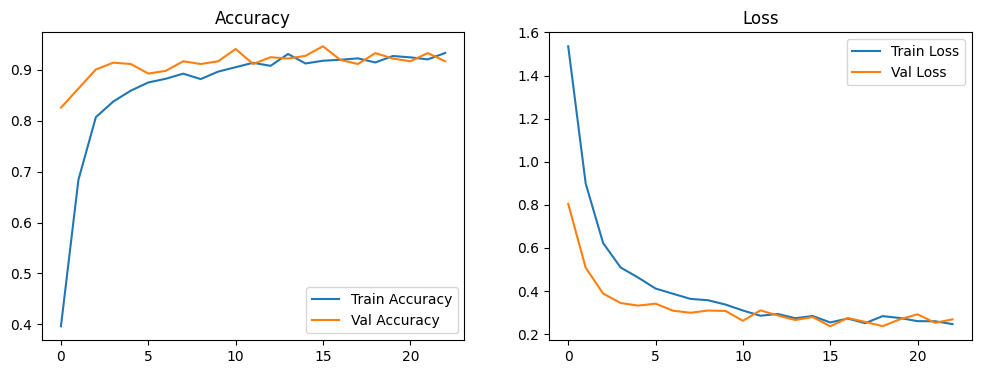

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    layers.Dropout(0.2),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

save_path = '/content/drive/MyDrive/mobilenet_temp2_sgd.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(save_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("start training")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weights_dict
)

start training
Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4708 - loss: 1.5088
Epoch 1: val_accuracy improved from -inf to 0.87936, saving model to /content/drive/MyDrive/mobilenet_temp2_sgd.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 199s 8s/step - accuracy: 0.4790 - loss: 1.4864 - val_accuracy: 0.8794 - val_loss: 0.4788 - learning_rate: 0.0100
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8711 - loss: 0.4115
Epoch 2: val_accuracy improved from 0.87936 to 0.91153, saving model to /content/drive/MyDrive/mobilenet_temp2_sgd.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 171s 7s/step - accuracy: 0.8715 - loss: 0.4105 - val_accuracy: 0.9115 - val_loss: 0.3228 - learning_rate: 0.0100
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9016 - loss: 0.3165
Epoch 3: val_accuracy improved from 0.91153 to 0.92493, saving model to /content/drive/MyDrive/mobilenet_temp2_sgd.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 170s 7s/step - accuracy: 0.9018 - loss: 0.3159 - val_accuracy: 0.9249

Start Training


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5680 - loss: 1.4070
Epoch 1: val_accuracy improved from -inf to 0.91957, saving model to /content/drive/MyDrive/mobilenet_exp6_labelsmoothing.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 245s 9s/step - accuracy: 0.5744 - loss: 1.3929 - val_accuracy: 0.9196 - val_loss: 0.6881
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8825 - loss: 0.7230
Epoch 2: val_accuracy improved from 0.91957 to 0.92493, saving model to /content/drive/MyDrive/mobilenet_exp6_labelsmoothing.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 201s 8s/step - accuracy: 0.8828 - loss: 0.7225 - val_accuracy: 0.9249 - val_loss: 0.6239
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9180 - loss: 0.6500
Epoch 3: val_accuracy did not improve from 0.92493
24/24 ━━━━━━━━━━━━━━━━━━━━ 178s 7s/step - accuracy: 0.9178 - loss: 0.6505 - val_accuracy: 0.9115 - val_loss: 0.6661
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9211 - loss: 0.6241
Epoch 4: v

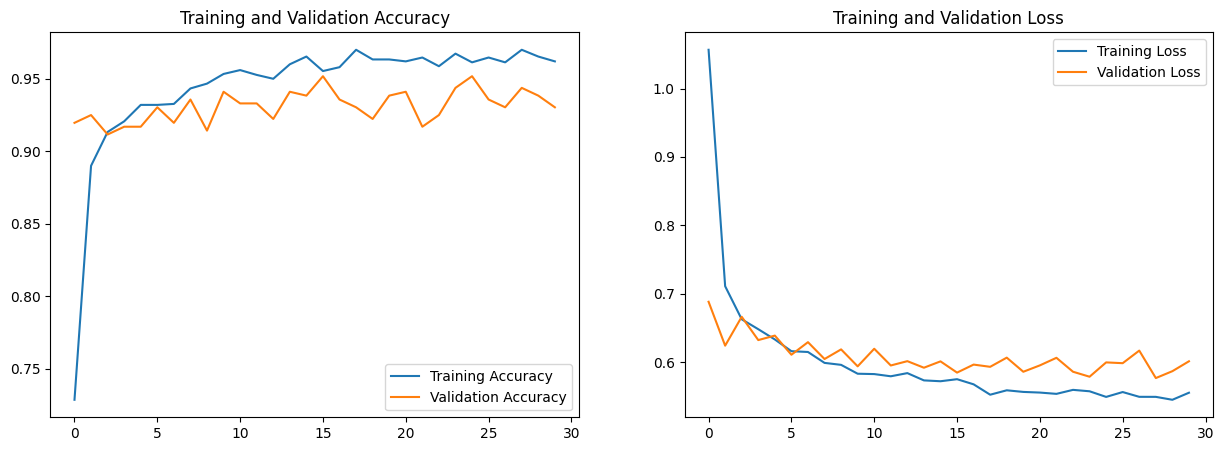

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt


initial_learning_rate = 0.001
decay_steps = 30 * len(train_data)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate, decay_steps, alpha=0.01
)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    layers.Dropout(0.2),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

save_path = '/content/drive/MyDrive/mobilenet_exp6_labelsmoothing.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(save_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("Start Training")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weights_dict
)

print("\n📊 Generating Plots...")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

2/6 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9609 - loss: 0.2543   

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - accuracy: 0.9523 - loss: 0.2852

 Final Test Accuracy: 93.57%
------------------------------
6/6 ━━━━━━━━━━━━━━━━━━━━ 47s 7s/step

              precision    recall  f1-score   support

    building       0.90      0.94      0.92        67
         car       0.98      0.96      0.97        95
         lab       0.94      1.00      0.97        44
      person       0.95      0.92      0.94        64
        tree       0.95      0.93      0.94       103

    accuracy                           0.95       373
   macro avg       0.94      0.95      0.95       373
weighted avg       0.95      0.95      0.95       373



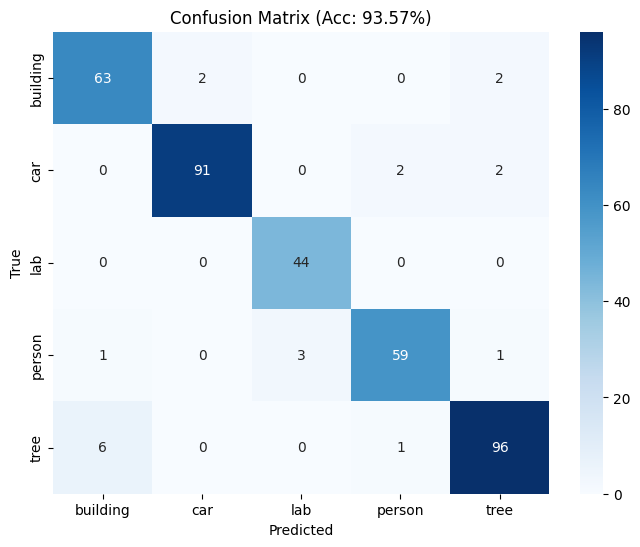

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

best_model_path = '/content/drive/MyDrive/mobilenet_exp6_labelsmoothing.keras'
final_model = load_model(best_model_path, compile=False)

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

val_data.reset()

loss, accuracy = final_model.evaluate(val_data, verbose=1)
print(f"\n Final Test Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)

Y_pred = final_model.predict(val_data, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_data.classes

class_names = list(val_data.class_indices.keys())

print("\n" + "="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Acc: {accuracy*100:.2f}%)')
plt.show()

Start Training
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3514 - loss: 7.7870
Epoch 1: val_accuracy improved from -inf to 0.80965, saving model to /content/drive/MyDrive/mobilenet_final_novelty.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 273s 10s/step - accuracy: 0.3564 - loss: 7.6641 - val_accuracy: 0.8097 - val_loss: 0.8365
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7404 - loss: 1.0096
Epoch 2: val_accuracy improved from 0.80965 to 0.88740, saving model to /content/drive/MyDrive/mobilenet_final_novelty.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 199s 8s/step - accuracy: 0.7416 - loss: 1.0072 - val_accuracy: 0.8874 - val_loss: 0.7447
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8169 - loss: 0.8622
Epoch 3: val_accuracy improved from 0.88740 to 0.89276, saving model to /content/drive/MyDrive/mobilenet_final_novelty.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 187s 8s/step - accuracy: 0.8173 - loss: 0.8615 - val_accuracy: 0.8928 - val_loss: 0.7516
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 

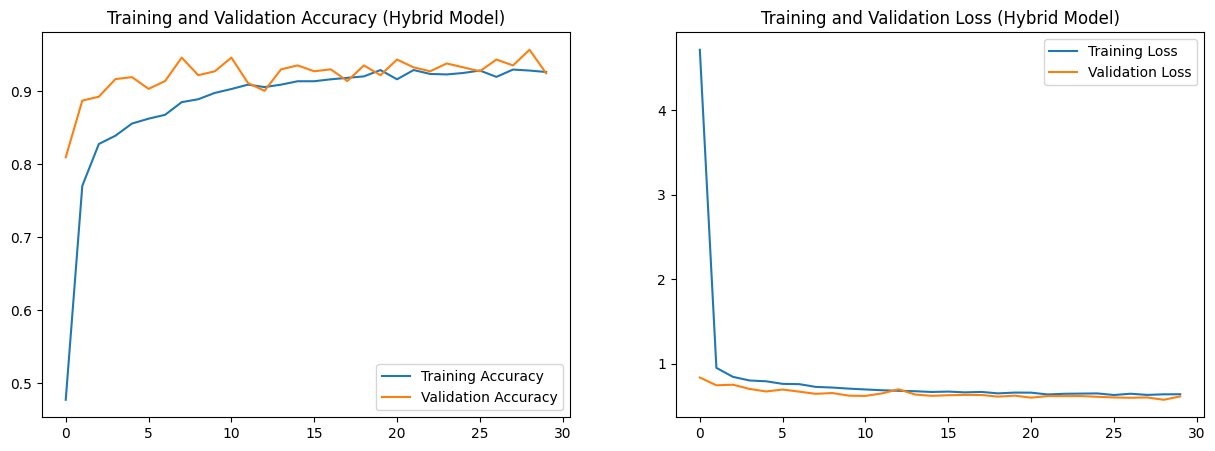

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

initial_learning_rate = 0.001
decay_steps = 30 * len(train_data)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate, decay_steps, alpha=0.01
)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

avg_pool = layers.GlobalAveragePooling2D(name="Global_Avg_Pool")(x)
max_pool = layers.GlobalMaxPooling2D(name="Global_Max_Pool")(x)
x = layers.Concatenate(name="Hybrid_Concatenation")([avg_pool, max_pool])

x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs, outputs, name="MobileNetV2_Hybrid_Pooling")

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

save_path = '/content/drive/MyDrive/mobilenet_final_novelty.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(save_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("Start Training")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weights_dict
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Hybrid Model)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Hybrid Model)')

plt.show()

2/6 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9883 - loss: 0.2287   

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 56s 8s/step - accuracy: 0.9614 - loss: 0.2716
Test Accuracy: 93.30%
6/6 ━━━━━━━━━━━━━━━━━━━━ 55s 8s/step

              precision    recall  f1-score   support

    building       0.84      0.99      0.90        67
         car       0.99      0.95      0.97        95
         lab       0.88      0.98      0.92        44
      person       0.93      0.89      0.91        64
        tree       0.96      0.86      0.91       103

    accuracy                           0.92       373
   macro avg       0.92      0.93      0.92       373
weighted avg       0.93      0.92      0.93       373



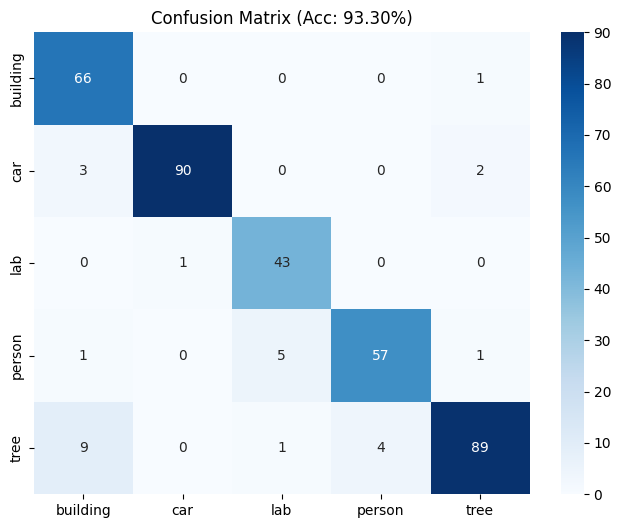

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

best_model_path = '/content/drive/MyDrive/mobilenet_final_novelty.keras'
final_model = load_model(best_model_path, compile=False)
final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

val_data.reset()
loss, accuracy = final_model.evaluate(val_data, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Y_pred = final_model.predict(val_data, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

print("\n" + "="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix (Acc: {accuracy*100:.2f}%)')
plt.show()